In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import os

In [2]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    # 'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]


In [19]:
dfs = []
for ds_name in ds_names:
    results_dict = {
        'Model': model_ls,
        'accuracy': [],
        'accuracy_withoutImg': [],
        'AUC_diff': []
    }

    print(ds_name)
    for ax_idx, model in enumerate(model_ls):
        
        #### AUC diff
        if model=='llava-1.5-7b' and ds_name=='MATE':
            path = f'{os.getcwd()}/../../results//{model}/svd/token/'
        else:
            path = f'{os.getcwd()}/../../results//{model}/svd//'

        # get the files
        if ds_name=='ScienceQA':
            files = [f for f in os.listdir(path) if ds_name in f and 'withoutHint_' in f and '.csv' in f]
        elif ds_name=='MATE':
            files = [f for f in os.listdir(path) if '.csv' in f and 'image_and_text' in f]
        else:    
            files = [f for f in os.listdir(path) if ds_name in f and 'without' not in f and '.csv' in f]
        # get plot_df  
        plot_df = []
        for idx, f in enumerate(files):
            df_ = pd.read_csv(path+f, index_col=0)
            if 'label' in df_.columns or 'sample' in df_.columns:
                df_ = df_.drop(['label','sample'],axis=1)
    
            df_ = df_.melt(['Mean over'])
            df_['layers'] = df_['variable'].astype(int)
            plot_df = plot_df + [df_]
        plot_df = pd.concat(plot_df).reset_index()
        
        mean_df = plot_df.groupby(["Mean over", "layers"]).mean(numeric_only=True).reset_index()
        auc_text = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Text tokens']['layers']/mean_df['layers'].max(), 
                                    mean_df[mean_df['Mean over']=='Text tokens']['value'])
    
        auc_img = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Img tokens']['layers']/mean_df['layers'].max(), 
                                    mean_df[mean_df['Mean over']=='Img tokens']['value'])
        results_dict['AUC_diff'] = results_dict['AUC_diff'] + [auc_text-auc_img]
        
        #### Calculate Accuracy - withIMG
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name == 'MATE':
                prediction_df = pd.read_csv(f'{path}/{file}')
                
            elif ds_name == 'ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHint_' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:  
                if '.csv' in file and ds_name in file and 'without' not in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            
        if ds_name == 'MATE':
            if model=='llava-1.5-7b':
                results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]  
            else:
               results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]
        else:
            results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]
        
        
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name=='ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHintwithoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:
                if '.csv' in file and ds_name in file and 'withoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')

        if ds_name=='MATE':
            results_dict['accuracy_withoutImg'] = [0.0]*len(model_ls),
        else:
            results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]
    
    results_df = pd.DataFrame(results_dict)
    results_df['accuracy_diff'] = results_df['accuracy'] - results_df['accuracy_withoutImg']
    results_df['ds_name'] = [ds_name]*len(model_ls)
    
    dfs = dfs + [results_df]

dfs = pd.concat(dfs)


ScienceQA
MicroVQA
MathVision
HallusionBench
BLINK
VstarBench


In [20]:
df = pd.DataFrame({
    'Model': model_ls,
    'accuracy':[
        0.1030909090909091, 
        0.2210909090909091, 
        0.3201818181818182, 
        0.24963636363636363, 
        0.6298181818181818, 
        0.7094545454545454, 
        0.6641818181818182, 
        0.6858181818181818
    ],
    'accuracy_withoutImg': [0.0]*len(model_ls),
    'AUC_diff': [
        122.3110200579637,
        93.47599844453124,
        114.76172467968749,
        68.26799382142858,
        47.66852175555554,
        54.64675147321428,
        52.68553216597221,
        76.03866390902778
    ],
    'accuracy_diff': [
        0.1030909090909091, 
        0.2210909090909091, 
        0.3201818181818182, 
        0.24963636363636363, 
        0.6298181818181818, 
        0.7094545454545454, 
        0.6641818181818182, 
        0.6858181818181818
    ],
    'ds_name': ['MATE']*len(model_ls)
})

dfs = pd.concat([dfs,df])
dfs['AUC_diff_abs'] = [np.abs(i) for i in dfs['AUC_diff']]

/tmp/ipykernel_2265583/3485465875.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_2265583/3485465875.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_2265583/3485465875.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_2265583/3485465875.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_2265583/3485465875.py:59: UserWarning: set_ticklabels() should only be used with a fixed numb

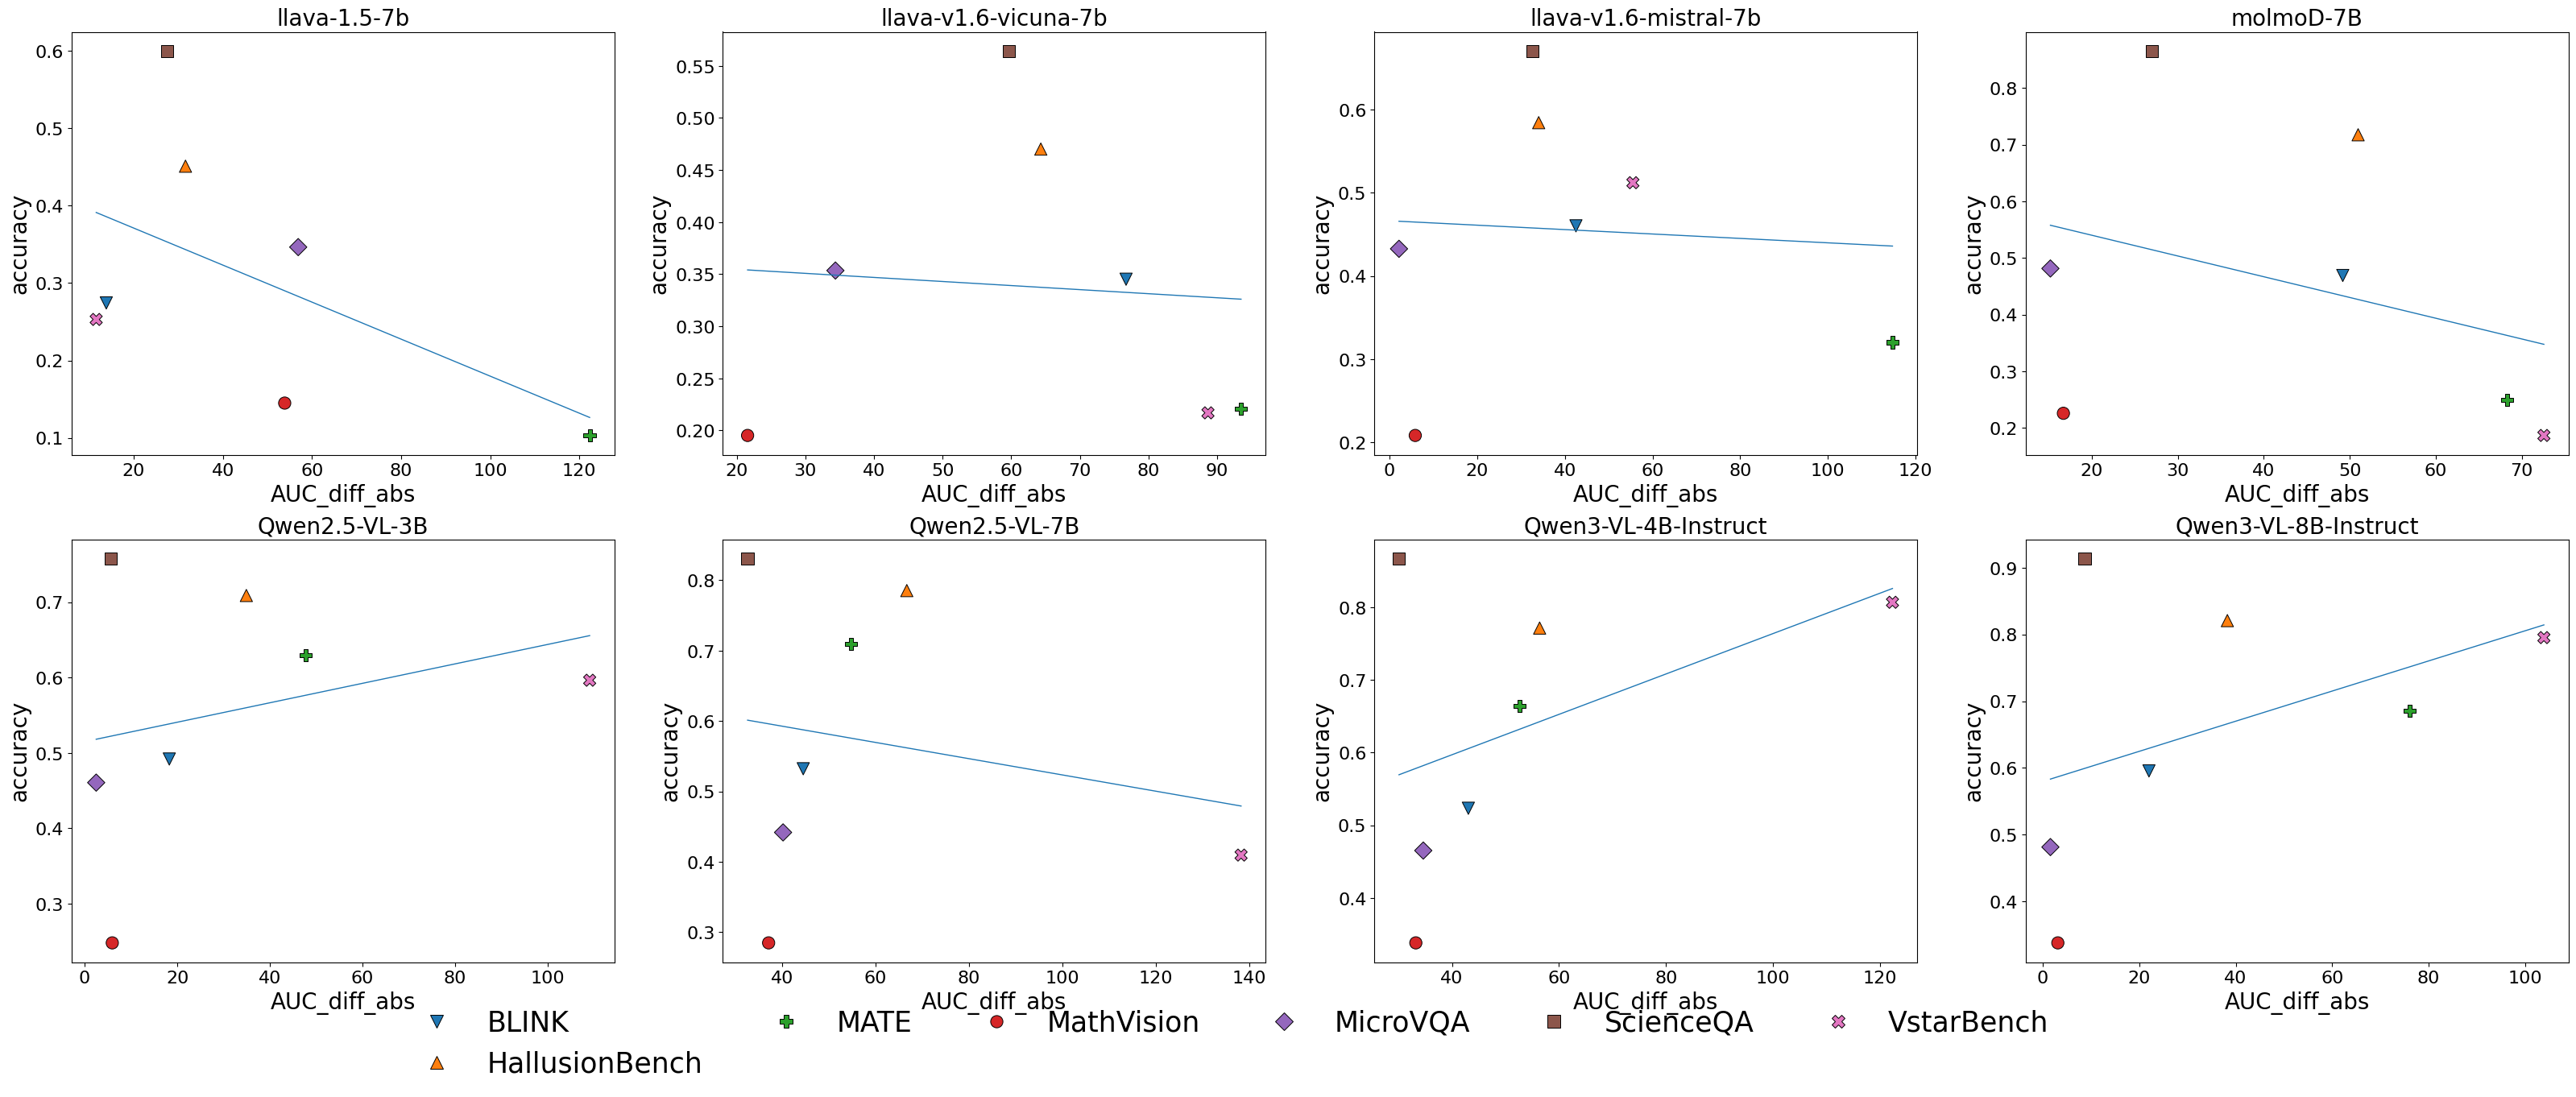

In [22]:
models = dfs["Model"].unique()
colors = {m: cm.tab20(i % 20) for i, m in enumerate(models)}
# dfs_ = dfs[dfs['ds_name']!='MATE']
dfs_ = dfs

# Markers per dataset
markers = {
    "MathVision": "o",        # circle
    "ScienceQA": "s",         # square
    "HallusionBench": "^",    # triangle up
    "MicroVQA": "D",              # diamond
    "BLINK": "v",           # triangle down
    "MATE": "P",            # plus (filled)
    "VstarBench":"X"
}

fig, axes = plt.subplots(2, 4, figsize=(40, 15))
axes = axes.flatten()

for ax_idx, model in enumerate(model_ls):
    ax = axes[ax_idx]

    sub = dfs_[dfs_["Model"] == model].sort_values("ds_name")
    sub['marker'] = [markers[i] for i in sub['ds_name']]
    # Scatter: one point per dataset
    # for _, row in sub.iterrows():
        # b = sns.scatterplot(
        #     x=[row["AUC_diff"]],
        #     y=[row["accuracy"]],
        #     ax=ax,
        #     hue='ds_name',
        #     # color=colors[model],
        #     # marker=markers[row["ds_name"]],
        #     # s=120,
        #     edgecolor="black",
        #     linewidth=0.7,
        #     legend=False
        # )

    b = sns.scatterplot(
        data=sub,
            x="AUC_diff_abs",
            y="accuracy",
            ax=ax,
            hue="ds_name",
            style="ds_name",
            markers=markers, 
            s=120,
            edgecolor="black",
            linewidth=0.7,
            legend="brief" if ax_idx==len(model_ls)-1 else False
    )
    sns.regplot(data=sub, x="AUC_diff_abs", y="accuracy", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})

    ax.set_title(model, fontsize=20)
    # ax.grid(True, alpha=0.3)
    # b.set_xticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], fontsize=16)
    b.set_xticklabels(b.get_xticklabels(), fontsize=16)
    b.set_yticklabels(b.get_yticklabels(), fontsize=16)
    b.set_xlabel(b.get_xlabel(), fontsize=20)
    b.set_ylabel(b.get_ylabel(), fontsize=20)
    

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),frameon=False, ncol=6, fontsize=25, loc=(-3,-0.3))
plt.tight_layout()
plt.show()



/tmp/ipykernel_2265583/1126893998.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_2265583/1126893998.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_2265583/1126893998.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_2265583/1126893998.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_2265583/1126893998.py:60: UserWarning: set_ticklabels() should only be used with a fixed numb

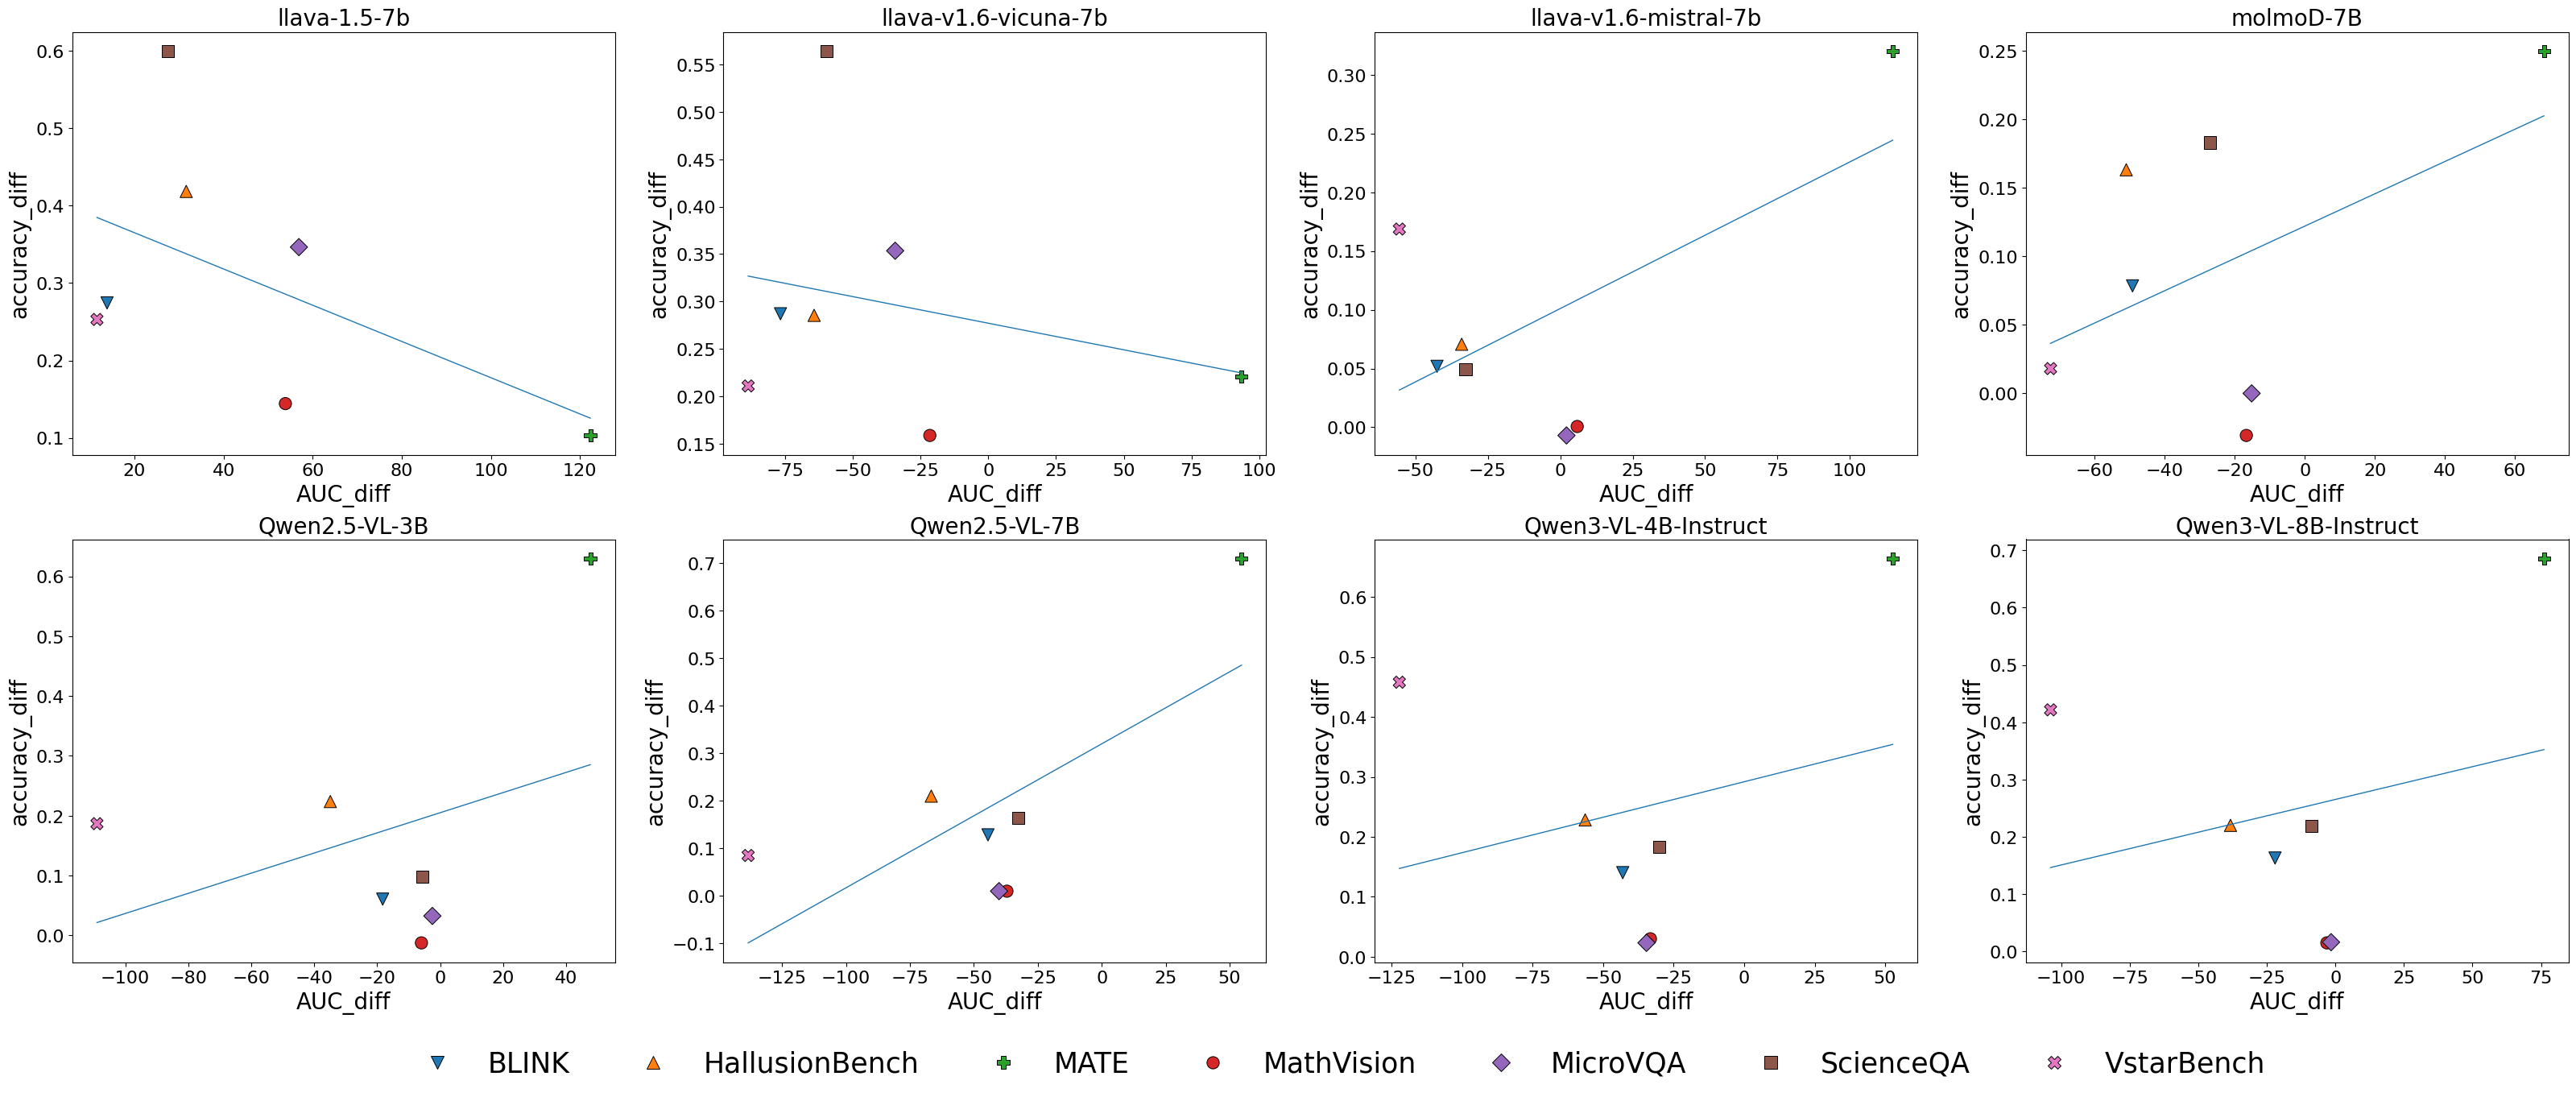

In [27]:
dfs['AUC_diff_abs'] = [np.abs(i) for i in dfs['AUC_diff']]
dfs_ = dfs[dfs['ds_name']!='MATE']
dfs_ = dfs

models = dfs_["Model"].unique()
colors = {m: cm.tab20(i % 20) for i, m in enumerate(models)}

# Markers per dataset
markers = {
    "MathVision": "o",        # circle
    "ScienceQA": "s",         # square
    "HallusionBench": "^",    # triangle up
    "MicroVQA": "D",              # diamond
    "BLINK": "v",           # triangle down
    "MATE": "P",            # plus (filled)
    "VstarBench":"X"
}

fig, axes = plt.subplots(2, 4, figsize=(40, 15))
axes = axes.flatten()

for ax_idx, model in enumerate(model_ls):
    ax = axes[ax_idx]

    sub = dfs_[dfs_["Model"] == model].sort_values("ds_name")
    sub['marker'] = [markers[i] for i in sub['ds_name']]
    # Scatter: one point per dataset
    # for _, row in sub.iterrows():
        # b = sns.scatterplot(
        #     x=[row["AUC_diff"]],
        #     y=[row["accuracy"]],
        #     ax=ax,
        #     hue='ds_name',
        #     # color=colors[model],
        #     # marker=markers[row["ds_name"]],
        #     # s=120,
        #     edgecolor="black",
        #     linewidth=0.7,
        #     legend=False
        # )

    b = sns.scatterplot(
        data=sub,
            x="AUC_diff",
            y="accuracy_diff",
            ax=ax,
            hue="ds_name",
            style="ds_name",
            markers=markers, 
            s=120,
            edgecolor="black",
            linewidth=0.7,
            legend="brief" if ax_idx==len(model_ls)-1 else False
    )
    sns.regplot(data=sub, x="AUC_diff", y="accuracy_diff", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})

    ax.set_title(model, fontsize=20)
    # ax.grid(True, alpha=0.3)
    b.set_xticklabels(b.get_xticklabels(), fontsize=16)
    b.set_yticklabels(b.get_yticklabels(), fontsize=16)
    b.set_xlabel(b.get_xlabel(), fontsize=20)
    b.set_ylabel(b.get_ylabel(), fontsize=20)
    

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),frameon=False, ncol=7, fontsize=25, loc=(-3,-0.3))
plt.tight_layout()
plt.show()
